# CARMA QMLE, recovered Levy driver, and driver-distribution diagnostics

This notebook uses the CARMA order and coefficients exported by `02order.ipynb`.

1. load the fixed CARMA coefficients selected in `02order.ipynb`;
2. estimate the Levy drift and variance by Gaussian prediction-error QMLE;
3. recover hourly Levy driver increments `Delta L` from the smoothed CARMA state;
4. fit Gaussian and NIG laws to the recovered `Delta L`;
5. simulate the selected CARMA model driven by those fitted drivers and compare the simulated levels `Y_t` with the empirical deseasonalised log-price residuals.

Vocabulary used below:

- `Delta L`: increment of the latent Levy driver;
- `Delta Y`: hourly difference of the observed/simulated CARMA output;
- `Y`: deseasonalised log-price residual / CARMA output level.

The NIG law is fitted to `Delta L`, not to `Delta Y`.


In [1]:
%matplotlib inline

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize
from scipy.special import kve
from scipy.stats import norm, norminvgauss

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "data" / "seasonality" / "french_panel.csv").exists():
    CODE = CWD
elif (CWD.parent / "data" / "seasonality" / "french_panel.csv").exists():
    CODE = CWD.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from notebooks/.")

DATA = CODE / "data"
OUT = DATA / "kalman"
FIG = CODE / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(DATA / "seasonality" / "french_panel.csv", index_col=0, parse_dates=True)
panel = panel.dropna(subset=["price_raw", "log_price", "log_price_seasonal", "log_price_resid"])

price_obs = panel["price_raw"].to_numpy(float)
log_price_obs = panel["log_price"].to_numpy(float)
log_price_seasonal = panel["log_price_seasonal"].to_numpy(float)
pr = panel["log_price_resid"].to_numpy(float)

valid = (
    np.isfinite(price_obs)
    & np.isfinite(log_price_obs)
    & np.isfinite(log_price_seasonal)
    & np.isfinite(pr)
)
panel = panel.loc[valid]
price_obs = price_obs[valid]
log_price_obs = log_price_obs[valid]
log_price_seasonal = log_price_seasonal[valid]
pr = pr[valid]

N = len(pr)
obs_delta_y = np.diff(pr)
obs_delta_log_price = np.diff(log_price_obs)
obs_delta_price = np.diff(price_obs)
price_shift = float(np.median(np.exp(log_price_obs) - price_obs))
seasonality_identity_error = float(np.max(np.abs(log_price_obs - log_price_seasonal - pr)))

print(f"{N:,} hourly deseasonalised log-price residuals")
print(f"Y empirical mean/std       = {pr.mean():.6e} / {pr.std(ddof=0):.6e}")
print(f"Delta Y empirical mean/std = {obs_delta_y.mean():.6e} / {obs_delta_y.std(ddof=0):.6e}")
print(f"log-price shift inferred   = {price_shift:.6f}")
print(f"max |log_price - seasonal - resid| = {seasonality_identity_error:.3e}")

17,521 hourly deseasonalised log-price residuals
Y empirical mean/std       = 3.935948e-05 / 2.827893e-02
Delta Y empirical mean/std = 4.690308e-06 / 1.035914e-02
log-price shift inferred   = 1000.000000
max |log_price - seasonal - resid| = 1.818e-15


## 1. Fixed CARMA state-space model

The AR and MA coefficients are fixed by the previous ACF/order-selection step. This notebook estimates only the driver drift/scale and then studies the recovered driver distribution.


In [2]:
def build_companion_matrix(ar_coefficients):
    ar = np.asarray(ar_coefficients, dtype=float)
    p = len(ar)
    A = np.zeros((p, p))
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -ar[::-1]

    expected = np.concatenate([[1.0], ar])
    actual = np.poly(np.linalg.eigvals(A)).real
    if not np.allclose(actual, expected, atol=1e-6):
        raise ValueError(f"Companion matrix check failed: {actual} vs {expected}")
    return A


def build_b_vector(b_coefficients, p):
    b = np.asarray(b_coefficients, dtype=float)
    q = len(b) - 1
    if q > p - 1:
        raise ValueError(f"q={q} must be <= p-1={p-1}")
    return np.concatenate([b, np.zeros(p - 1 - q)]) if q < p - 1 else b.copy()


def psd_sqrt(M, tol=1e-12):
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"Matrix is not PSD; min eigenvalue={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def discrete_noise_covariance(A, ep, Delta=1.0):
    # Van Loan block exponential for int_0^Delta exp(Au) e e' exp(A'u) du.
    A = np.asarray(A, dtype=float)
    ep = np.asarray(ep, dtype=float)
    p = A.shape[0]
    M = np.zeros((2 * p, 2 * p))
    M[:p, :p] = A
    M[:p, p:] = np.outer(ep, ep)
    M[p:, p:] = -A.T
    E = expm(M * Delta)
    F_block = E[:p, :p]
    Q = E[:p, p:] @ F_block.T
    return 0.5 * (Q + Q.T)


def distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    s = pd.Series(x)
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(ddof=0),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.quantile(0.50),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "skew": s.skew(),
        "excess_kurtosis": s.kurt(),
    })


def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    return np.array([1.0] + [float(np.dot(x[:-k], x[k:]) / denom) for k in range(1, max_lag + 1)])


with open(OUT / "price_multiscale_carma_selected.json") as f:
    cfg = json.load(f)

ar_coefficients = np.array(cfg["ar_coefficients"], dtype=float)
b_coefficients = np.array(cfg["b_coefficients"], dtype=float)
roots = np.array(cfg["roots"], dtype=float)

p = len(ar_coefficients)
q = len(b_coefficients) - 1
Delta = 1.0
model_name = f"CARMA({p},{q})"
model_tag = f"carma{p}{q}"

A = build_companion_matrix(ar_coefficients)
ep = np.zeros(p)
ep[-1] = 1.0
b_vec = build_b_vector(b_coefficients, p)
F = expm(A * Delta)
Pi1 = solve_continuous_lyapunov(A, -np.outer(ep, ep))
Q_base = discrete_noise_covariance(A, ep, Delta)
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)
dc_gain = float(b_coefficients[0] / ar_coefficients[-1])

if not np.all(roots[:, 0] < 0):
    raise ValueError("Non-causal CARMA roots detected.")

print(model_name)
print(f"b_vec = {np.array2string(b_vec, precision=6)}")
print(f"max Re(root) = {roots[:, 0].max():.6e}")
print(f"Pi1 min eig  = {np.linalg.eigvalsh(Pi1).min():.3e}")
print(f"Qbase min eig = {np.linalg.eigvalsh(Q_base).min():.3e}")
print(f"DC gain b(0)/a(0) = {dc_gain:.6e}")

CARMA(5,4)
b_vec = [1.921698e-05 1.525443e-02 7.728508e-02 2.605489e-01 1.000000e+00]
max Re(root) = -4.125876e-04
Pi1 min eig  = 8.389e-01
Qbase min eig = 3.114e-08
DC gain b(0)/a(0) = 6.005185e+01


## 2. Gaussian prediction-error QMLE

The CARMA coefficients are fixed. QMLE estimates the Levy drift rate `m` and variance rate `nu2` using the Gaussian prediction-error likelihood.

In [3]:
def kalman_filter_fixed_params(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    U_hat = np.zeros(p)
    Pi = Pi1.copy()
    Psi = np.zeros((p, p))
    Omega = Pi.copy()

    residuals = np.empty(n)
    r_array = np.empty(n)
    Uhat_trace = np.empty((n, p))

    for i in range(n):
        Omega_b = Omega @ b_vec
        Delta_i = float(b_vec @ Omega_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        Theta = F @ Omega_b
        resid = series[i] - float(b_vec @ U_hat)

        residuals[i] = resid
        r_array[i] = Delta_i
        Uhat_trace[i] = U_hat.copy()

        Pi_new = F @ Pi @ F.T + Q_base
        Psi_new = F @ Psi @ F.T + np.outer(Theta, Theta) / Delta_i
        Omega = Pi_new - Psi_new
        Omega = 0.5 * (Omega + Omega.T)
        Pi = Pi_new
        Psi = Psi_new
        U_hat = F @ U_hat + (Theta / Delta_i) * resid

    return residuals, r_array, Uhat_trace


def estimate_m_nu2(y, ar_coeffs, b_coeffs, Delta=1.0):
    y = np.asarray(y, dtype=float)
    n = len(y)
    p = len(ar_coeffs)

    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)

    dc_gain_loc = float(b_coeffs[0] / ar_coeffs[-1])

    e_raw, r, _ = kalman_filter_fixed_params(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, y)
    residuals_c, _, _ = kalman_filter_fixed_params(
        A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, np.ones(n)
    )
    coef = dc_gain_loc * residuals_c

    m_hat = float(np.sum(e_raw * coef / r) / np.sum(coef ** 2 / r))
    residuals = e_raw - m_hat * coef
    nu2_hat = float(np.sum(residuals ** 2 / r) / n)
    loglik = -0.5 * (n * np.log(2.0 * np.pi * nu2_hat) + np.sum(np.log(r)) + n)

    return {
        "m_hat": m_hat,
        "nu2_hat": nu2_hat,
        "loglik": float(loglik),
        "r_array": r,
        "residuals": residuals,
        "e_raw": e_raw,
        "coef": coef,
    }


qmle = estimate_m_nu2(pr, ar_coefficients, b_coefficients, Delta=Delta)
m_hat = qmle["m_hat"]
nu2_hat = qmle["nu2_hat"]
r_array = qmle["r_array"]
eps_adj = qmle["residuals"]
eps_std = eps_adj / np.sqrt(nu2_hat * r_array)

qmle_json = {
    "m_qmle": float(m_hat),
    "nu2_qmle": float(nu2_hat),
    "loglik_qmle": float(qmle["loglik"]),
    "stationary_mean": float(m_hat * dc_gain),
    "carma_order": [int(p), int(q)],
    "source": "notebooks/03mle.ipynb",
}
qmle_path = OUT / f"price_{model_tag}_qmle_result.json"
qmle_path.write_text(json.dumps(qmle_json, indent=2))
(OUT / "price_carma_qmle_result.json").write_text(json.dumps(qmle_json, indent=2))

print(f"m_hat              = {m_hat:.6e}")
print(f"nu2_hat            = {nu2_hat:.6e}  sqrt={np.sqrt(nu2_hat):.6e}")
print(f"stationary mean Y  = {m_hat * dc_gain:.6e}")
print(f"loglik             = {qmle['loglik']:.3f}")
print(f"standardised innovations mean/std = {eps_std.mean():.4f} / {eps_std.std(ddof=0):.4f}")
print(f"Saved: {qmle_path.name} and price_carma_qmle_result.json")

m_hat              = -3.805413e-05
nu2_hat            = 1.368840e-04  sqrt=1.169974e-02
stationary mean Y  = -2.285221e-03
loglik             = 55631.802
standardised innovations mean/std = 0.0040 / 1.0000
Saved: price_carma54_qmle_result.json and price_carma_qmle_result.json


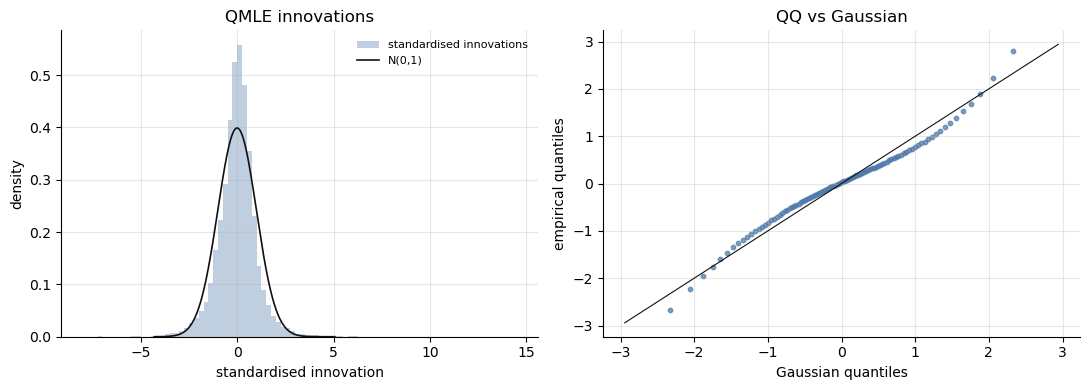

Saved: price_carma54_qmle_innovation_diagnostics.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(eps_std, bins=90, density=True, color="#4c78a8", alpha=0.35, label="standardised innovations")
x = np.linspace(np.quantile(eps_std, 0.001), np.quantile(eps_std, 0.999), 600)
ax.plot(x, norm.pdf(x), color="#111111", lw=1.2, label="N(0,1)")
ax.set_title("QMLE innovations")
ax.set_xlabel("standardised innovation")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
probs = np.linspace(0.01, 0.99, 99)
emp_q = np.quantile(eps_std, probs)
norm_q = norm.ppf(probs)
lim = max(abs(emp_q).max(), abs(norm_q).max()) * 1.05
ax.scatter(norm_q, emp_q, s=10, color="#4c78a8", alpha=0.7)
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("QQ vs Gaussian")
ax.set_xlabel("Gaussian quantiles")
ax.set_ylabel("empirical quantiles")

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_qmle_innovation_diagnostics.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

## 3. Recover hourly Levy driver increments

This keeps the previous recovery method: Kalman filtered states, RTS smoothing, then the Brockwell-Lindner modal recovery formula.

In [5]:
def kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    x_pred = np.zeros(p)
    P_pred = Pi1.copy()

    pred_states = np.empty((n, p))
    pred_covs = np.empty((n, p, p))
    filt_states = np.empty((n, p))
    filt_covs = np.empty((n, p, p))
    next_pred_states = np.empty((n, p))
    next_pred_covs = np.empty((n, p, p))
    residuals = np.empty(n)
    r_array = np.empty(n)

    for i in range(n):
        pred_states[i] = x_pred
        pred_covs[i] = P_pred

        P_b = P_pred @ b_vec
        Delta_i = float(b_vec @ P_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        resid = series[i] - float(b_vec @ x_pred)
        gain = P_b / Delta_i
        x_filt = x_pred + gain * resid
        P_filt = P_pred - np.outer(P_b, P_b) / Delta_i
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_next = F @ x_filt
        P_next = F @ P_filt @ F.T + Q_base
        P_next = 0.5 * (P_next + P_next.T)

        residuals[i] = resid
        r_array[i] = Delta_i
        filt_states[i] = x_filt
        filt_covs[i] = P_filt
        next_pred_states[i] = x_next
        next_pred_covs[i] = P_next

        x_pred = x_next
        P_pred = P_next

    return {
        "residuals": residuals,
        "r_array": r_array,
        "pred_states": pred_states,
        "pred_covs": pred_covs,
        "filt_states": filt_states,
        "filt_covs": filt_covs,
        "next_pred_states": next_pred_states,
        "next_pred_covs": next_pred_covs,
    }


def rts_smoother(F, filt_states, filt_covs, next_pred_states, next_pred_covs):
    n, p = filt_states.shape
    smooth_states = filt_states.copy()
    smooth_covs = filt_covs.copy()

    for i in range(n - 2, -1, -1):
        J = np.linalg.solve(next_pred_covs[i].T, (filt_covs[i] @ F.T).T).T
        smooth_states[i] = filt_states[i] + J @ (smooth_states[i + 1] - next_pred_states[i])
        smooth_covs[i] = filt_covs[i] + J @ (smooth_covs[i + 1] - next_pred_covs[i]) @ J.T
        smooth_covs[i] = 0.5 * (smooth_covs[i] + smooth_covs[i].T)

    return smooth_states, smooth_covs


def build_modal_matrix(A, roots_complex):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    p = len(roots_complex)
    E = np.column_stack([lam ** np.arange(p) for lam in roots_complex])
    for r, lam in enumerate(roots_complex):
        err = np.linalg.norm(A @ E[:, r] - lam * E[:, r])
        if err >= 1e-8:
            raise ValueError(f"Eigenvector check failed for root {r}: err={err:.3e}")
    return E, np.linalg.inv(E)


def parse_roots(ar_coeffs, roots=None):
    if roots is None:
        return np.roots(np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)]))
    return np.array([r[0] + 1j * r[1] if hasattr(r, "__len__") else complex(r) for r in roots])


def select_recovery_root(roots_complex, tol=1e-8):
    real_mask = np.abs(roots_complex.imag) < tol
    if not np.any(real_mask):
        raise ValueError("No real root available for modal recovery.")
    ridx = np.where(real_mask)[0]
    return int(ridx[np.argmin(np.abs(roots_complex[ridx].real))])


def levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=None, Delta=1.0):
    X_hat = np.asarray(X_hat, dtype=float)
    roots_complex = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    _, E_inv = build_modal_matrix(A_loc, roots_complex)

    idx_r = select_recovery_root(roots_complex)
    lam_r = float(roots_complex[idx_r].real)

    b_lam = float(sum(c * lam_r ** k for k, c in enumerate(b_coeffs)))
    xi_r = (E_inv @ X_hat.T)[idx_r]
    imag_frac = np.abs(xi_r.imag).max() / (np.abs(xi_r.real).max() + 1e-30)
    if imag_frac > 1e-6:
        raise ValueError(f"Imaginary residual too large in modal coordinate: {imag_frac:.2e}")

    Y_r = b_lam * xi_r.real
    a_desc = np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)])
    a_prime = float(np.polyval(np.polyder(a_desc), lam_r))
    alpha_r = b_lam / a_prime

    times = np.arange(len(Y_r)) * Delta
    integ = cumulative_trapezoid(Y_r, times, initial=0.0)
    L_hat = (Y_r - Y_r[0] - lam_r * integ) / alpha_r

    return {
        "L_hat": L_hat,
        "increments": np.diff(L_hat),
        "Y_r": Y_r,
        "lambda_r": lam_r,
        "idx_r": idx_r,
        "alpha_r": float(alpha_r),
    }


def recover_levy_increments(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, roots=None, Delta=1.0):
    y = np.asarray(y, dtype=float)
    p = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc = float(b_coeffs[0] / ar_coeffs[-1])

    W = y - m_hat * dc
    filt = kalman_filter_state_estimates(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, W)
    U_smooth, _ = rts_smoother(
        F_loc,
        filt["filt_states"],
        filt["filt_covs"],
        filt["next_pred_states"],
        filt["next_pred_covs"],
    )

    obs_resid = W - U_smooth @ b_loc
    shift = np.linalg.solve(-A_loc, ep_loc)
    X_hat = U_smooth + m_hat * shift

    out = levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=roots, Delta=Delta)
    out["state_path"] = X_hat
    out["obs_resid_max"] = float(np.max(np.abs(obs_resid)))
    out["nu2_hat"] = float(nu2_hat)
    out["m_hat"] = float(m_hat)
    return out


levy_out = recover_levy_increments(
    pr,
    ar_coefficients,
    b_coefficients,
    m_hat=m_hat,
    nu2_hat=nu2_hat,
    roots=cfg["roots"],
    Delta=Delta,
)

L_hat = levy_out["L_hat"]
driver_delta_l = levy_out["increments"]

levy_npz_path = OUT / f"price_{model_tag}_levy_increments_recovered.npz"
np.savez(
    levy_npz_path,
    L_hat=L_hat,
    increments=driver_delta_l,
    Y_r=levy_out["Y_r"],
    lambda_r=np.array([levy_out["lambda_r"]]),
    idx_r=np.array([levy_out["idx_r"]], dtype=int),
    alpha_r=np.array([levy_out["alpha_r"]]),
    nu2_hat=np.array([nu2_hat]),
    m_hat=np.array([m_hat]),
    obs_resid_max=np.array([levy_out["obs_resid_max"]]),
)

recovery_half_life_h = np.log(2.0) / (-levy_out["lambda_r"])
print(f"Selected recovery root lambda = {levy_out['lambda_r']:.6e}")
print(f"Selected recovery root half-life = {recovery_half_life_h:.3f} h = {recovery_half_life_h / 24.0:.3f} d")
print(f"Recovered Delta L mean/std    = {driver_delta_l.mean():.6e} / {driver_delta_l.std(ddof=0):.6e}")
print(f"Recovered Delta L var / nu2   = {np.var(driver_delta_l) / nu2_hat:.6f}")
print(f"Max smoother observation residual = {levy_out['obs_resid_max']:.3e}")
print(f"Saved: {levy_npz_path.name}")

Selected recovery root lambda = -4.125876e-04
Selected recovery root half-life = 1680.000 h = 70.000 d
Recovered Delta L mean/std    = 1.347449e-05 / 1.165249e-02
Recovered Delta L var / nu2   = 0.991939
Max smoother observation residual = 5.128e-13
Saved: price_carma54_levy_increments_recovered.npz


## 4. Fit Gaussian and NIG laws to recovered `Delta L`

These fits are driver fits. They are not fits to `Delta Y`.

In [6]:
def log_nig_pdf_save03(x, mu, delta, alpha, beta):
    x = np.asarray(x, dtype=float)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    xm = x - mu
    r = np.sqrt(delta * delta + xm * xm)
    return (
        np.log(alpha * delta / np.pi)
        + delta * gamma
        + beta * xm
        + np.log(kve(1, alpha * r))
        - alpha * r
        - np.log(r)
    )


def fit_nig_manual(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    mu_g = float(x.mean())
    sig_g = float(x.std(ddof=1))
    kurt_raw = float(np.mean((x - mu_g) ** 4) / sig_g ** 4)
    skew_raw = float(np.mean((x - mu_g) ** 3) / sig_g ** 3)

    alpha0 = np.sqrt(3.0 / (sig_g ** 2 * max(kurt_raw - 3.0, 0.01)))
    delta0 = sig_g ** 2 * alpha0
    beta0 = np.clip(
        skew_raw * alpha0 * np.sqrt(delta0 * alpha0) / 3.0,
        -0.9 * alpha0,
        0.9 * alpha0,
    )

    def pack(mu, delta, alpha, beta):
        return np.array([mu, np.log(delta), np.log(alpha), np.arctanh(beta / (0.99 * alpha))])

    def unpack(theta):
        mu = theta[0]
        delta = np.exp(theta[1])
        alpha = np.exp(theta[2])
        beta = np.tanh(theta[3]) * 0.99 * alpha
        return mu, delta, alpha, beta

    def nll(theta):
        mu, delta, alpha, beta = unpack(theta)
        ll = log_nig_pdf_save03(x, mu, delta, alpha, beta)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return -float(ll.sum())

    theta0 = pack(mu_g, delta0, alpha0, beta0)
    best = None
    for beta_shift in np.linspace(-0.5, 0.5, 5):
        res = minimize(nll, theta0 + np.array([0.0, 0.0, 0.0, beta_shift]),
                       method="L-BFGS-B", options={"maxiter": 800, "ftol": 1e-10})
        if best is None or res.fun < best.fun:
            best = res

    mu, delta, alpha, beta = unpack(best.x)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    return {
        "mu": float(mu),
        "delta": float(delta),
        "alpha": float(alpha),
        "beta": float(beta),
        "gamma": float(gamma),
        "scipy_a": float(alpha * delta),
        "scipy_b": float(beta * delta),
        "scipy_loc": float(mu),
        "scipy_scale": float(delta),
        "loglik": float(-best.fun),
        "mean": float(mu + delta * beta / gamma),
        "variance": float(delta * alpha * alpha / gamma ** 3),
        "std": float(np.sqrt(delta * alpha * alpha / gamma ** 3)),
        "skew": float(3 * beta / (alpha * np.sqrt(delta * gamma))),
        "excess_kurtosis": float(3 * (1 + 4 * beta * beta / (alpha * alpha)) / (delta * gamma)),
        "success": bool(best.success),
        "message": str(best.message),
        "N": int(len(x)),
    }


dL = np.asarray(driver_delta_l, dtype=float)
gaussian_driver = {
    "mean": float(dL.mean()),
    "variance": float(dL.var(ddof=0)),
    "std": float(dL.std(ddof=0)),
    "m_rate": float(dL.mean() / Delta),
    "nu2_rate": float(dL.var(ddof=0) / Delta),
    "N": int(len(dL)),
}
nig_driver = fit_nig_manual(dL)

driver_fits = {
    "gaussian": gaussian_driver,
    "nig": nig_driver,
    "source": "recovered hourly Levy increments from notebooks/03mle.ipynb",
}
driver_fits_path = OUT / f"price_{model_tag}_driver_fits.json"
driver_fits_path.write_text(json.dumps(driver_fits, indent=2))

print("Gaussian driver fit on Delta L")
print(f"  mean/std = {gaussian_driver['mean']:.6e} / {gaussian_driver['std']:.6e}")
print("NIG driver fit on Delta L")
print(f"  mu,delta,alpha,beta = {nig_driver['mu']:.6e}, {nig_driver['delta']:.6e}, {nig_driver['alpha']:.6e}, {nig_driver['beta']:.6e}")
print(f"  mean/std            = {nig_driver['mean']:.6e} / {nig_driver['std']:.6e}")
print(f"  skew/kurt           = {nig_driver['skew']:.4f} / {nig_driver['excess_kurtosis']:.4f}")
print(f"Saved: {driver_fits_path.name}")

Gaussian driver fit on Delta L
  mean/std = 1.347449e-05 / 1.165249e-02
NIG driver fit on Delta L
  mu,delta,alpha,beta = 5.499197e-04, 9.778414e-03, 7.292412e+01, -3.994622e+00
  mean/std            = 1.347431e-05 / 1.160586e-02
  skew/kurt           = -0.1948 / 4.2640
Saved: price_carma54_driver_fits.json


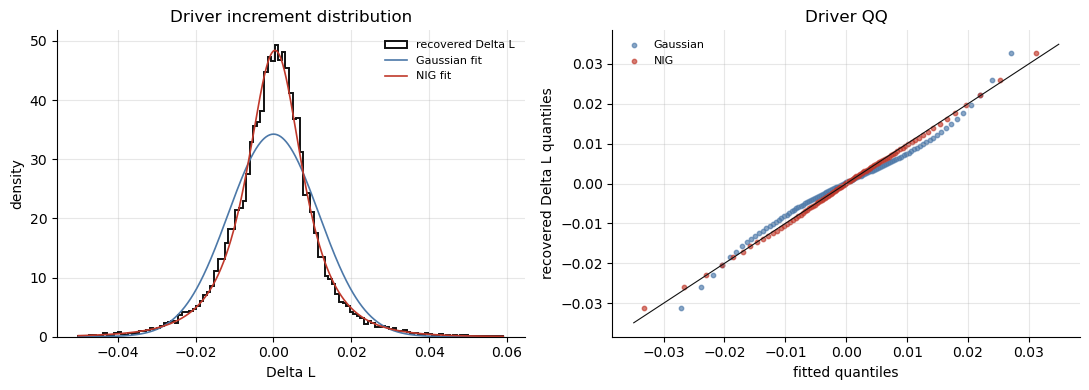

Saved: price_carma54_driver_deltaL_fits.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0]
bins = np.linspace(np.quantile(dL, 0.001), np.quantile(dL, 0.999), 120)
x = np.linspace(bins[0], bins[-1], 700)
ax.hist(dL, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="recovered Delta L")
ax.plot(x, norm.pdf(x, gaussian_driver["mean"], gaussian_driver["std"]),
        color="#4c78a8", lw=1.2, label="Gaussian fit")
ax.plot(x, norminvgauss.pdf(x, nig_driver["scipy_a"], nig_driver["scipy_b"],
                            loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        color="#c0392b", lw=1.2, label="NIG fit")
ax.set_title("Driver increment distribution")
ax.set_xlabel("Delta L")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
obs_q = np.quantile(dL, probs)
gauss_q = norm.ppf(probs, gaussian_driver["mean"], gaussian_driver["std"])
nig_q = norminvgauss.ppf(probs, nig_driver["scipy_a"], nig_driver["scipy_b"],
                         loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"])
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Driver QQ")
ax.set_xlabel("fitted quantiles")
ax.set_ylabel("recovered Delta L quantiles")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_driver_deltaL_fits.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

## 5. Simulate selected CARMA model with fitted drivers

Gaussian driver simulation uses the exact sampled CARMA transition.

For NIG, the exact one-hour state shock is the stochastic integral

`int_0^1 exp(A(1-u)) e dL_u`.

The notebook uses one NIG driver increment per hour and a midpoint kernel for a simple diagnostic. It does not simulate sub-hour paths and should not be read as an exact NIG transition likelihood.


In [8]:
def simulate_gaussian_carma_exact(A, b_vec, F, Q_base, Pi1, ep, driver_fit,
                                  n_steps, n_paths, seed=20260621):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    m_rate = driver_fit["m_rate"]
    nu2_rate = driver_fit["nu2_rate"]

    state_mean = m_rate * np.linalg.solve(-A, ep)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q_base)
    g = np.linalg.solve(A, (F - np.eye(p)) @ ep)

    X = state_mean + np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))

    for t in range(n_steps):
        shocks = np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + m_rate * g + shocks
        Y[:, t] = X @ b_vec

    return Y


def simulate_nig_carma_midpoint(A, b_vec, F, ep, nig_fit,
                                n_steps, n_paths, burnin=5000, seed=20260622):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    shock_vec = expm(A * 0.5) @ ep
    mean_dL = nig_fit["mean"]
    state_mean = np.linalg.solve(np.eye(p) - F, shock_vec * mean_dL)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))

    dL_all = norminvgauss.rvs(
        nig_fit["scipy_a"],
        nig_fit["scipy_b"],
        loc=nig_fit["scipy_loc"],
        scale=nig_fit["scipy_scale"],
        size=(n_paths, n_steps + burnin),
        random_state=rng,
    )

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL_all[:, t, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y, dL_all[:, burnin:]


N_PATHS = 250
gaussian_paths = simulate_gaussian_carma_exact(
    A, b_vec, F, Q_base, Pi1, ep, gaussian_driver,
    n_steps=N, n_paths=N_PATHS, seed=20260621,
)
nig_paths, nig_driver_draws = simulate_nig_carma_midpoint(
    A, b_vec, F, ep, nig_driver,
    n_steps=N, n_paths=N_PATHS, burnin=5000, seed=20260622,
)

gaussian_delta_y = np.diff(gaussian_paths, axis=1)
nig_delta_y = np.diff(nig_paths, axis=1)

print(f"Gaussian exact CARMA paths: {gaussian_paths.shape}")
print(f"NIG midpoint CARMA paths  : {nig_paths.shape}")
print(f"Gaussian Y mean/std       : {gaussian_paths.mean():.6e} / {gaussian_paths.std(ddof=0):.6e}")
print(f"NIG Y mean/std            : {nig_paths.mean():.6e} / {nig_paths.std(ddof=0):.6e}")
print(f"Observed Y mean/std       : {pr.mean():.6e} / {pr.std(ddof=0):.6e}")

Gaussian exact CARMA paths: (250, 17521)
NIG midpoint CARMA paths  : (250, 17521)
Gaussian Y mean/std       : 1.249528e-03 / 2.701737e-02
NIG Y mean/std            : 8.559003e-04 / 2.699051e-02
Observed Y mean/std       : 3.935948e-05 / 2.827893e-02


In [9]:
summary = pd.DataFrame({
    "observed_Y": distribution_summary(pr),
    "gaussian_CARMA_Y": distribution_summary(gaussian_paths),
    "nig_CARMA_Y": distribution_summary(nig_paths),
    "observed_DeltaY": distribution_summary(obs_delta_y),
    "gaussian_CARMA_DeltaY": distribution_summary(gaussian_delta_y),
    "nig_CARMA_DeltaY": distribution_summary(nig_delta_y),
    "recovered_DeltaL": distribution_summary(dL),
    "nig_simulated_DeltaL": distribution_summary(nig_driver_draws),
}).T

summary_path = OUT / f"price_{model_tag}_distribution_summary.csv"
summary.to_csv(summary_path)
print(summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {summary_path}")

                              mean          std           q01           q05        median          q95          q99          skew  excess_kurtosis
observed_Y            3.935948e-05 2.827893e-02 -6.539966e-02 -4.653493e-02 -5.769734e-04 4.601551e-02 6.121396e-02  9.253750e-02     7.710296e-01
gaussian_CARMA_Y      1.249528e-03 2.701737e-02 -6.155816e-02 -4.310391e-02  1.215960e-03 4.576144e-02 6.429752e-02  6.941856e-03     5.686153e-03
nig_CARMA_Y           8.559003e-04 2.699051e-02 -6.302233e-02 -4.354295e-02  9.198792e-04 4.498528e-02 6.406698e-02 -2.025728e-02     1.542922e-01
observed_DeltaY       4.690308e-06 1.035914e-02 -2.823819e-02 -1.618205e-02  2.609263e-04 1.579290e-02 3.006003e-02  1.586653e-01     7.695523e+00
gaussian_CARMA_DeltaY 3.707857e-08 1.052485e-02 -2.446286e-02 -1.730339e-02 -1.182284e-05 1.732399e-02 2.450666e-02  2.519053e-03    -3.739953e-03
nig_CARMA_DeltaY      1.981147e-07 1.035763e-02 -2.899248e-02 -1.654104e-02  1.475261e-04 1.603630e-02 2.732382e-02 -1

In [10]:
max_lag = 336
lags = np.arange(max_lag + 1)
acf_obs = acf_1d(pr, max_lag)
acf_gaussian = np.mean([acf_1d(path, max_lag) for path in gaussian_paths], axis=0)
acf_nig = np.mean([acf_1d(path, max_lag) for path in nig_paths], axis=0)

acf_diag_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_table = pd.DataFrame({
    "lag": acf_diag_lags,
    "observed": acf_obs[acf_diag_lags],
    "gaussian_CARMA": acf_gaussian[acf_diag_lags],
    "nig_CARMA": acf_nig[acf_diag_lags],
})
print(acf_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

 lag  observed  gaussian_CARMA  nig_CARMA
   1  0.932752        0.921280   0.923642
   2  0.866383        0.866914   0.870835
   3  0.815006        0.825980   0.830784
   6  0.723791        0.735412   0.741508
  12  0.661529        0.619376   0.626226
  24  0.623201        0.563939   0.570659
  48  0.425265        0.384205   0.392113
  72  0.322932        0.270860   0.280236
 168  0.123464        0.108569   0.118656
 336  0.147241        0.071077   0.076609


## 6. Posterior predictive checks

These checks compare the realised empirical path with the distribution of statistics obtained from simulated CARMA paths. The key question is whether the observed statistic is typical under the model, not only whether two histograms look similar.


In [11]:
PPC_LAGS = [1, 6, 24, 72, 168, 336]


def acf_selected_lags(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    vals = []
    for lag in lags:
        if lag <= 0:
            vals.append(1.0)
        elif lag >= len(x) or denom <= 0.0:
            vals.append(np.nan)
        else:
            vals.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(vals, dtype=float)


def skew_and_excess_kurtosis(x):
    x = np.asarray(x, dtype=float)
    z = x - x.mean()
    sd = z.std(ddof=0)
    if sd <= 0.0:
        return np.nan, np.nan
    z = z / sd
    return float(np.mean(z ** 3)), float(np.mean(z ** 4) - 3.0)


def path_ppc_stats(y, lags=PPC_LAGS):
    y = np.asarray(y, dtype=float)
    dy = np.diff(y)
    skew_y, kurt_y = skew_and_excess_kurtosis(y)
    _, kurt_dy = skew_and_excess_kurtosis(dy)

    out = {
        "Y_std": float(np.std(y, ddof=0)),
        "Y_skew": skew_y,
        "Y_excess_kurtosis": kurt_y,
        "Y_q01": float(np.quantile(y, 0.01)),
        "Y_q05": float(np.quantile(y, 0.05)),
        "Y_q95": float(np.quantile(y, 0.95)),
        "Y_q99": float(np.quantile(y, 0.99)),
        "DeltaY_std": float(np.std(dy, ddof=0)),
        "DeltaY_excess_kurtosis": kurt_dy,
        "DeltaY_q01": float(np.quantile(dy, 0.01)),
        "DeltaY_q99": float(np.quantile(dy, 0.99)),
    }

    acf_y = acf_selected_lags(y, lags)
    acf_dy = acf_selected_lags(dy, lags)
    for lag, val in zip(lags, acf_y):
        out[f"ACF_Y_{lag}h"] = float(val)
    for lag, val in zip(lags, acf_dy):
        out[f"ACF_DeltaY_{lag}h"] = float(val)
    return pd.Series(out)


def simulated_ppc_stats(paths, lags=PPC_LAGS):
    rows = [path_ppc_stats(path, lags=lags) for path in np.asarray(paths)]
    return pd.DataFrame(rows)


def posterior_predictive_table(observed_stats, simulated_stats, model):
    rows = []
    for metric, observed in observed_stats.items():
        sims = simulated_stats[metric].dropna().to_numpy(float)
        q025, q50, q975 = np.quantile(sims, [0.025, 0.50, 0.975])
        obs_percentile = float(np.mean(sims <= observed))
        two_sided_p = float(min(1.0, 2.0 * min(obs_percentile, 1.0 - obs_percentile)))
        rows.append({
            "model": model,
            "metric": metric,
            "observed": float(observed),
            "sim_mean": float(np.mean(sims)),
            "sim_sd": float(np.std(sims, ddof=1)),
            "sim_q025": float(q025),
            "sim_q50": float(q50),
            "sim_q975": float(q975),
            "obs_percentile": obs_percentile,
            "two_sided_p": two_sided_p,
            "inside_95": bool(q025 <= observed <= q975),
            "n_paths": int(len(sims)),
        })
    return pd.DataFrame(rows)


observed_ppc = path_ppc_stats(pr)
gaussian_ppc_paths = simulated_ppc_stats(gaussian_paths)
nig_ppc_paths = simulated_ppc_stats(nig_paths)

ppc_table = pd.concat([
    posterior_predictive_table(observed_ppc, gaussian_ppc_paths, "Gaussian CARMA"),
    posterior_predictive_table(observed_ppc, nig_ppc_paths, "NIG CARMA"),
], ignore_index=True)

ppc_path = OUT / f"price_{model_tag}_posterior_predictive_checks.csv"
ppc_table.to_csv(ppc_path, index=False)

display_cols = [
    "metric",
    "observed",
    "sim_mean",
    "sim_q025",
    "sim_q975",
    "obs_percentile",
    "two_sided_p",
    "inside_95",
]

print("NIG CARMA posterior predictive checks")
print(
    ppc_table.loc[ppc_table["model"] == "NIG CARMA", display_cols]
    .to_string(index=False, float_format=lambda v: f"{v:.6e}")
)

print("\nMetrics outside the 95% posterior predictive envelope")
outliers = ppc_table.loc[~ppc_table["inside_95"], ["model"] + display_cols]
if len(outliers) == 0:
    print("None")
else:
    print(outliers.to_string(index=False, float_format=lambda v: f"{v:.6e}"))

print(f"\nSaved: {ppc_path}")


NIG CARMA posterior predictive checks
                metric      observed      sim_mean      sim_q025      sim_q975  obs_percentile  two_sided_p  inside_95
                 Y_std  2.827893e-02  2.658405e-02  2.472192e-02  2.918538e-02    9.200000e-01 1.600000e-01       True
                Y_skew  9.252958e-02 -2.438405e-02 -2.034450e-01  1.478905e-01    9.000000e-01 2.000000e-01       True
     Y_excess_kurtosis  7.704671e-01  1.403583e-01 -1.343691e-01  4.527582e-01    1.000000e+00 0.000000e+00      False
                 Y_q01 -6.539966e-02 -6.205936e-02 -7.349966e-02 -5.137025e-02    2.600000e-01 5.200000e-01       True
                 Y_q05 -4.653493e-02 -4.291440e-02 -5.245827e-02 -3.365073e-02    2.360000e-01 4.720000e-01       True
                 Y_q95  4.601551e-02  4.433826e-02  3.479516e-02  5.409017e-02    6.200000e-01 7.600000e-01       True
                 Y_q99  6.121396e-02  6.291194e-02  5.154363e-02  7.555242e-02    3.640000e-01 7.280000e-01       True
          

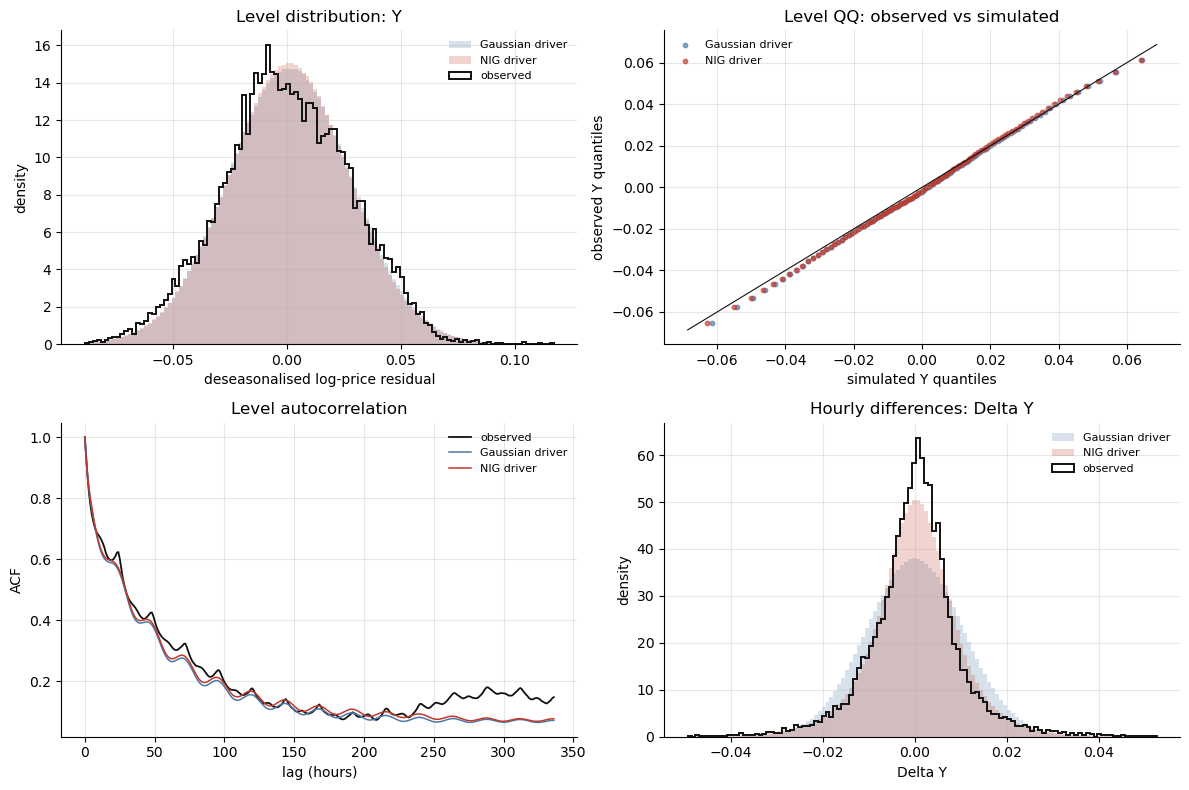

Saved: price_carma54_level_distribution_comparison.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_y = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(gaussian_paths, 0.001), np.quantile(nig_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(gaussian_paths, 0.999), np.quantile(nig_paths, 0.999)),
    120,
)
ax.hist(gaussian_paths.ravel(), bins=bins_y, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_paths.ravel(), bins=bins_y, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(pr, bins=bins_y, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Level distribution: Y")
ax.set_xlabel("deseasonalised log-price residual")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(pr, probs)
gauss_q = np.quantile(gaussian_paths.ravel(), probs)
nig_q = np.quantile(nig_paths.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Level QQ: observed vs simulated")
ax.set_xlabel("simulated Y quantiles")
ax.set_ylabel("observed Y quantiles")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(lags, acf_obs, color="#111111", lw=1.3, label="observed")
ax.plot(lags, acf_gaussian, color="#4c78a8", lw=1.1, label="Gaussian driver")
ax.plot(lags, acf_nig, color="#c0392b", lw=1.1, label="NIG driver")
ax.set_title("Level autocorrelation")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("ACF")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
bins_dy = np.linspace(
    min(np.quantile(obs_delta_y, 0.001), np.quantile(gaussian_delta_y, 0.001), np.quantile(nig_delta_y, 0.001)),
    max(np.quantile(obs_delta_y, 0.999), np.quantile(gaussian_delta_y, 0.999), np.quantile(nig_delta_y, 0.999)),
    120,
)
ax.hist(gaussian_delta_y.ravel(), bins=bins_dy, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_delta_y.ravel(), bins=bins_dy, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(obs_delta_y, bins=bins_dy, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Hourly differences: Delta Y")
ax.set_xlabel("Delta Y")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_level_distribution_comparison.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

## 7. Final log-price and price checks

The final observed log-price is `log_price_seasonal + log_price_resid`. This section compares the empirical final series with the theoretical seasonal component plus simulated CARMA stochastic components. It then maps back to raw prices with `price = exp(log_price) - shift`.


                           mean          std           q01           q05       median          q95          q99          skew  excess_kurtosis    delta_std     delta_q01    delta_q99
observed_log_price 6.964915e+00 4.114377e-02  6.897390e+00  6.907755e+00 6.965279e+00 7.030857e+00 7.062649e+00  3.062084e-01     2.110528e-01 1.453758e-02 -3.854806e-02 4.407834e-02
gaussian_log_price 6.966125e+00 4.023389e-02  6.872980e+00  6.899375e+00 6.966569e+00 7.031516e+00 7.056433e+00 -5.094367e-02    -1.586435e-01 1.472609e-02 -3.220772e-02 3.607726e-02
nig_log_price      6.965731e+00 4.018294e-02  6.872378e+00  6.899060e+00 6.966261e+00 7.030950e+00 7.055754e+00 -5.883545e-02    -1.344646e-01 1.460703e-02 -3.452962e-02 3.658368e-02
observed_price     5.972479e+01 4.389905e+01 -1.031200e+01  0.000000e+00 5.921000e+01 1.310000e+02 1.675340e+02  4.441056e-01     6.416694e-01 1.563236e+01 -4.049290e+01 4.707860e+01
gaussian_price     6.096433e+01 4.265700e+01 -3.417722e+01 -8.344770e+00 6.057807e+01

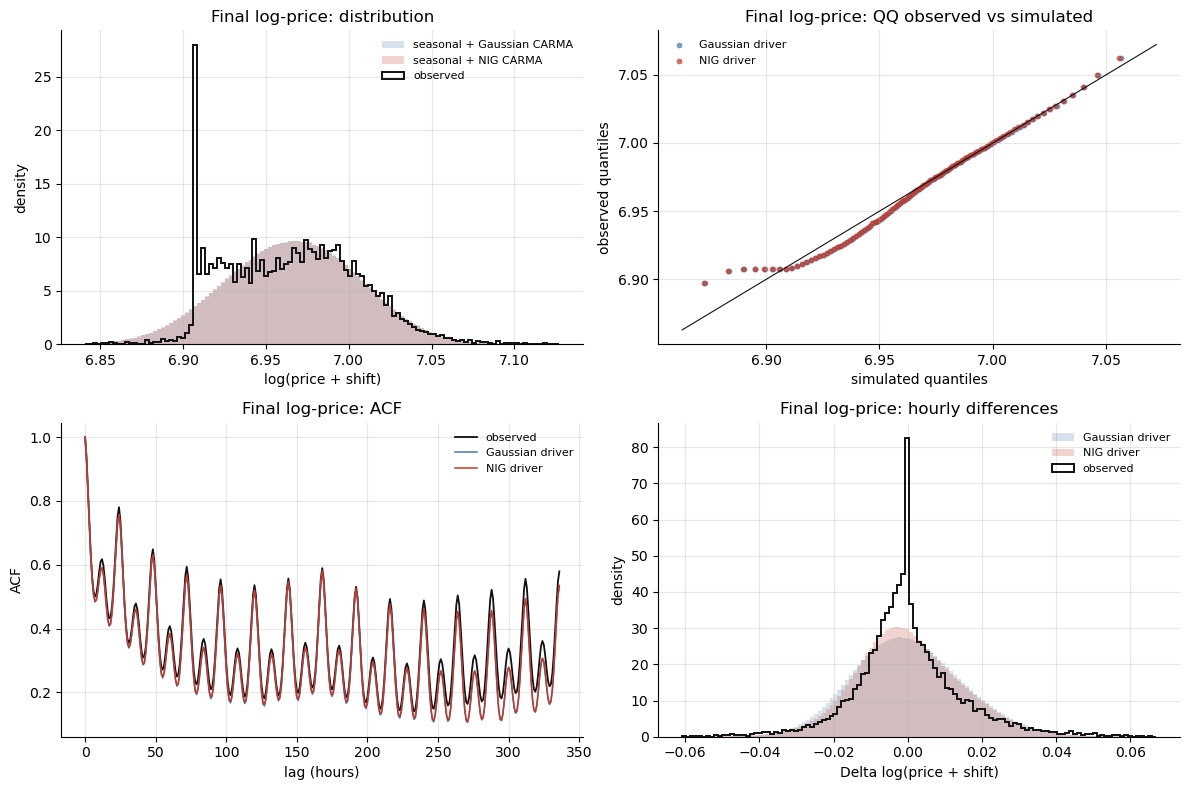

Saved: price_carma54_final_logprice_comparison.png


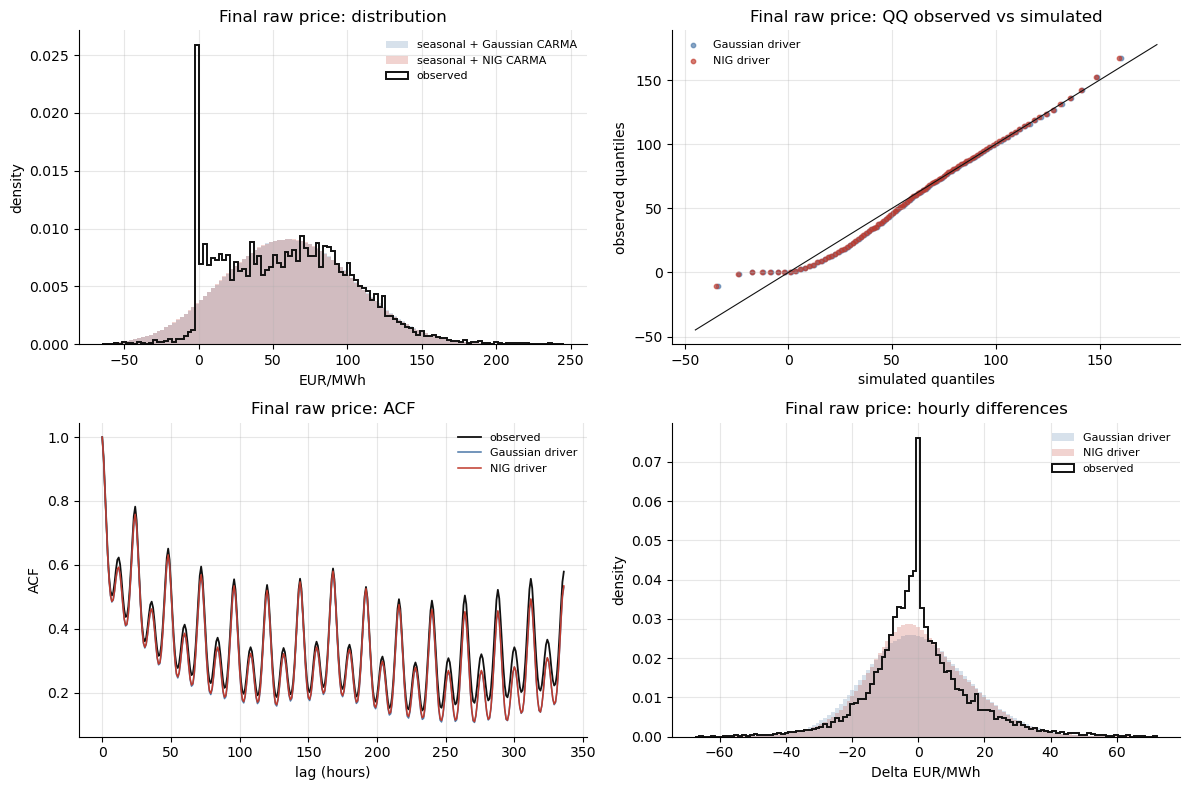

Saved: price_carma54_final_price_comparison.png


In [13]:
def final_distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    dx = np.diff(x)
    return pd.Series({
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=0)),
        "q01": float(np.quantile(x, 0.01)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.quantile(x, 0.50)),
        "q95": float(np.quantile(x, 0.95)),
        "q99": float(np.quantile(x, 0.99)),
        "skew": float(pd.Series(x).skew()),
        "excess_kurtosis": float(pd.Series(x).kurt()),
        "delta_std": float(np.std(dx, ddof=0)),
        "delta_q01": float(np.quantile(dx, 0.01)),
        "delta_q99": float(np.quantile(dx, 0.99)),
    })


def plot_final_series_checks(observed, gaussian_sim, nig_sim, observed_delta, gaussian_delta, nig_delta,
                             acf_max_lag, title_prefix, xlabel, delta_xlabel, fig_path):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    probs = np.linspace(0.01, 0.99, 99)

    ax = axes[0, 0]
    bins = np.linspace(
        min(np.quantile(observed, 0.001), np.quantile(gaussian_sim, 0.001), np.quantile(nig_sim, 0.001)),
        max(np.quantile(observed, 0.999), np.quantile(gaussian_sim, 0.999), np.quantile(nig_sim, 0.999)),
        120,
    )
    ax.hist(gaussian_sim.ravel(), bins=bins, density=True, color="#4c78a8", alpha=0.22, label="seasonal + Gaussian CARMA")
    ax.hist(nig_sim.ravel(), bins=bins, density=True, color="#c0392b", alpha=0.22, label="seasonal + NIG CARMA")
    ax.hist(observed, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: distribution")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[0, 1]
    obs_q = np.quantile(observed, probs)
    gauss_q = np.quantile(gaussian_sim.ravel(), probs)
    nig_q = np.quantile(nig_sim.ravel(), probs)
    lim_lo = min(obs_q.min(), gauss_q.min(), nig_q.min())
    lim_hi = max(obs_q.max(), gauss_q.max(), nig_q.max())
    pad = 0.05 * (lim_hi - lim_lo)
    ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
    ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
    ax.plot([lim_lo - pad, lim_hi + pad], [lim_lo - pad, lim_hi + pad], color="#111111", lw=0.8)
    ax.set_title(f"{title_prefix}: QQ observed vs simulated")
    ax.set_xlabel("simulated quantiles")
    ax.set_ylabel("observed quantiles")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 0]
    lag_grid = np.arange(acf_max_lag + 1)
    acf_obs_final = acf_1d(observed, acf_max_lag)
    acf_gauss_final = np.mean([acf_1d(path, acf_max_lag) for path in gaussian_sim], axis=0)
    acf_nig_final = np.mean([acf_1d(path, acf_max_lag) for path in nig_sim], axis=0)
    ax.plot(lag_grid, acf_obs_final, color="#111111", lw=1.3, label="observed")
    ax.plot(lag_grid, acf_gauss_final, color="#4c78a8", lw=1.1, label="Gaussian driver")
    ax.plot(lag_grid, acf_nig_final, color="#c0392b", lw=1.1, label="NIG driver")
    ax.set_title(f"{title_prefix}: ACF")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("ACF")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 1]
    bins_delta = np.linspace(
        min(np.quantile(observed_delta, 0.001), np.quantile(gaussian_delta, 0.001), np.quantile(nig_delta, 0.001)),
        max(np.quantile(observed_delta, 0.999), np.quantile(gaussian_delta, 0.999), np.quantile(nig_delta, 0.999)),
        120,
    )
    ax.hist(gaussian_delta.ravel(), bins=bins_delta, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
    ax.hist(nig_delta.ravel(), bins=bins_delta, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
    ax.hist(observed_delta, bins=bins_delta, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: hourly differences")
    ax.set_xlabel(delta_xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.savefig(fig_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path.name}")


if gaussian_paths.shape[1] != N or nig_paths.shape[1] != N:
    raise ValueError(
        f"Simulated paths length mismatch: gaussian={gaussian_paths.shape[1]}, "
        f"nig={nig_paths.shape[1]}, observed={N}"
    )

gaussian_log_price_paths = log_price_seasonal[None, :] + gaussian_paths
nig_log_price_paths = log_price_seasonal[None, :] + nig_paths

gaussian_price_paths = np.exp(gaussian_log_price_paths) - price_shift
nig_price_paths = np.exp(nig_log_price_paths) - price_shift

gaussian_delta_log_price = np.diff(gaussian_log_price_paths, axis=1)
nig_delta_log_price = np.diff(nig_log_price_paths, axis=1)
gaussian_delta_price = np.diff(gaussian_price_paths, axis=1)
nig_delta_price = np.diff(nig_price_paths, axis=1)

final_summary = pd.DataFrame({
    "observed_log_price": final_distribution_summary(log_price_obs),
    "gaussian_log_price": final_distribution_summary(gaussian_log_price_paths),
    "nig_log_price": final_distribution_summary(nig_log_price_paths),
    "observed_price": final_distribution_summary(price_obs),
    "gaussian_price": final_distribution_summary(gaussian_price_paths),
    "nig_price": final_distribution_summary(nig_price_paths),
}).T

final_summary_path = OUT / f"price_{model_tag}_final_logprice_price_summary.csv"
final_summary.to_csv(final_summary_path)
print(final_summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {final_summary_path}")

plot_final_series_checks(
    observed=log_price_obs,
    gaussian_sim=gaussian_log_price_paths,
    nig_sim=nig_log_price_paths,
    observed_delta=obs_delta_log_price,
    gaussian_delta=gaussian_delta_log_price,
    nig_delta=nig_delta_log_price,
    acf_max_lag=336,
    title_prefix="Final log-price",
    xlabel="log(price + shift)",
    delta_xlabel="Delta log(price + shift)",
    fig_path=FIG / f"price_{model_tag}_final_logprice_comparison.png",
)

plot_final_series_checks(
    observed=price_obs,
    gaussian_sim=gaussian_price_paths,
    nig_sim=nig_price_paths,
    observed_delta=obs_delta_price,
    gaussian_delta=gaussian_delta_price,
    nig_delta=nig_delta_price,
    acf_max_lag=336,
    title_prefix="Final raw price",
    xlabel="EUR/MWh",
    delta_xlabel="Delta EUR/MWh",
    fig_path=FIG / f"price_{model_tag}_final_price_comparison.png",
)


## 8. Key diagnostic identity

If the simulated levels have too much variance but their hourly differences look close, the likely reason is an autocorrelation compensation:

`Var(Delta Y) = 2 Var(Y) (1 - rho_1)`.

In [14]:
def level_delta_identity(name, y):
    y = np.asarray(y, dtype=float).ravel()
    dy = np.diff(y)
    var_y = float(np.var(y))
    var_dy = float(np.var(dy))
    rho1 = 1.0 - var_dy / (2.0 * var_y)
    return pd.Series({
        "std_Y": np.sqrt(var_y),
        "std_DeltaY": np.sqrt(var_dy),
        "rho1_implied": rho1,
        "varY_over_observed": var_y / np.var(pr),
        "varDeltaY_over_observed": var_dy / np.var(obs_delta_y),
    }, name=name)


identity = pd.DataFrame([
    level_delta_identity("observed", pr),
    level_delta_identity("gaussian_CARMA", gaussian_paths),
    level_delta_identity("nig_CARMA", nig_paths),
])

print(identity.to_string(float_format=lambda v: f"{v:.6e}"))

                      std_Y   std_DeltaY  rho1_implied  varY_over_observed  varDeltaY_over_observed
observed       2.827893e-02 1.035914e-02  9.329048e-01        1.000000e+00             1.000000e+00
gaussian_CARMA 2.701737e-02 1.052769e-02  9.240811e-01        9.127673e-01             1.032805e+00
nig_CARMA      2.699051e-02 1.036139e-02  9.263142e-01        9.109533e-01             1.000435e+00
